# Stationary audio review: localization_20260707_193328_0 (1).db3

## tl;dr

The bag is not one continuous quiet/stationary acoustic interval. The first ~43 s and final ~22 s are low-noise; the middle interval begins when the vehicle arms in ALT_HOLD and contains severe broadband interference and clipping. The strongest quiet-state tone is ~21,332.86 Hz, not 21,164 or 27,211 Hz. Both recorded channels are bit-identical.

## Context & Methods

### Key Assumptions

- `/audio_stamped` is S32LE stereo at 96 kHz as declared by `/audio_info`.
- Odom is not used as stationary ground truth. Vehicle state transitions are used only to align acoustic regime changes.
- A spectral line is not labeled as the pinger unless an independent ON/OFF or frequency label is available.
- Frequency and phase statistics are computed separately for quiet and armed/noisy intervals.

In [1]:
from pathlib import Path
import json
import numpy as np
from analysis.localization_20260707_stationary_audio import load_audio, analyze

bag_path = Path('/home/robot/Downloads/localization_20260707_193328_0 (1).db3')
output_dir = Path('/home/robot/uuv_sim_current/analysis/localization_20260707_stationary_audio')
summary = json.loads((output_dir / 'stationary_audio_summary.json').read_text())
summary['metadata']

{'packet_count': 47005,
 'sample_count': 45124800,
 'frames_per_packet_mode': 960,
 'packet_frame_min': 960,
 'packet_frame_max': 960,
 'channels_bit_identical': True,
 'clipping_sample_count': 2698465,
 'clipping_fraction': 0.059800043435095554,
 'header_start_s': 1783420408.6513884,
 'header_end_s': 1783420878.6913884,
 'header_duration_s': 470.039999961853,
 'header_dt_median_ms': 9.999990463256836,
 'header_dt_p99_ms': 10.000228881835938,
 'header_gap_over_15ms_count': 0,
 'bag_duration_s': 470.0682108402252}

## Data

The complete bag contains 470.05 s of audio. The derived time series below uses non-overlapping one-second spectral windows.

In [2]:
series = np.load(output_dir / 'stationary_audio_timeseries.npz')
quiet_mask = series['rms'] < 0.03
quiet_runs = []
start = None
for index, is_quiet in enumerate(quiet_mask):
    if is_quiet and start is None:
        start = index
    if start is not None and (not is_quiet or index == len(quiet_mask) - 1):
        stop = index if not is_quiet else index + 1
        if stop - start >= 2:
            quiet_runs.append((start, stop))
        start = None
quiet_runs

[(0, 43), (448, 470)]

## Results

Recompute the quiet-start, armed/noisy-middle, and quiet-end intervals directly from the original bag.

In [3]:
audio, metadata = load_audio(bag_path)
segments = {}
for name, start_s, stop_s in [('quiet_start', 0, 43), ('armed_noisy', 45, 448), ('quiet_end', 448, 470)]:
    result, _ = analyze(audio[start_s * 96000:stop_s * 96000])
    segments[name] = {
        'interval_s': [start_s, stop_s],
        'rms_median_fs': result['signal_rms_median'],
        'dominant_frequency_hz': result['dominant_frequency_hz'],
        'frequency_std_hz': result['dominant_frequency_per_second_std_hz'],
        'phase_residual_10s_rms_rad': result['phase_residual_10s_rms_rad'],
        'phase_step_over_90deg_fraction': result['phase_step_over_90deg_fraction'],
        'snr_21164_db_median': result['snr_21164_db_median'],
        'snr_27211_db_median': result['snr_27211_db_median'],
        'top_peaks': result['top_spectral_peaks_18_30khz'][:5],
    }
segments

{'quiet_start': {'interval_s': [0, 43],
  'rms_median_fs': 0.015467414151916475,
  'dominant_frequency_hz': 21332.86450918982,
  'frequency_std_hz': 0.06726095650794116,
  'phase_residual_10s_rms_rad': 0.18992985409271787,
  'phase_step_over_90deg_fraction': 0.0,
  'snr_21164_db_median': -1.3992020086570187,
  'snr_27211_db_median': 10.954308783531461,
  'top_peaks': [{'frequency_hz': 21332.86450918982,
    'psd_dbfs_per_hz': -40.95369021402676},
   {'frequency_hz': 28611.090467012655, 'psd_dbfs_per_hz': -66.3920943750925},
   {'frequency_hz': 19846.491291976814, 'psd_dbfs_per_hz': -70.38933494628259},
   {'frequency_hz': 20377.455952703738, 'psd_dbfs_per_hz': -70.44883176771448},
   {'frequency_hz': 25070.275203312165,
    'psd_dbfs_per_hz': -70.4432243946866}]},
 'armed_noisy': {'interval_s': [45, 448],
  'rms_median_fs': 0.3623473689546413,
  'dominant_frequency_hz': 23890.677949219214,
  'frequency_std_hz': 338.31674043511856,
  'phase_residual_10s_rms_rad': 8.920943245263425,
  'p

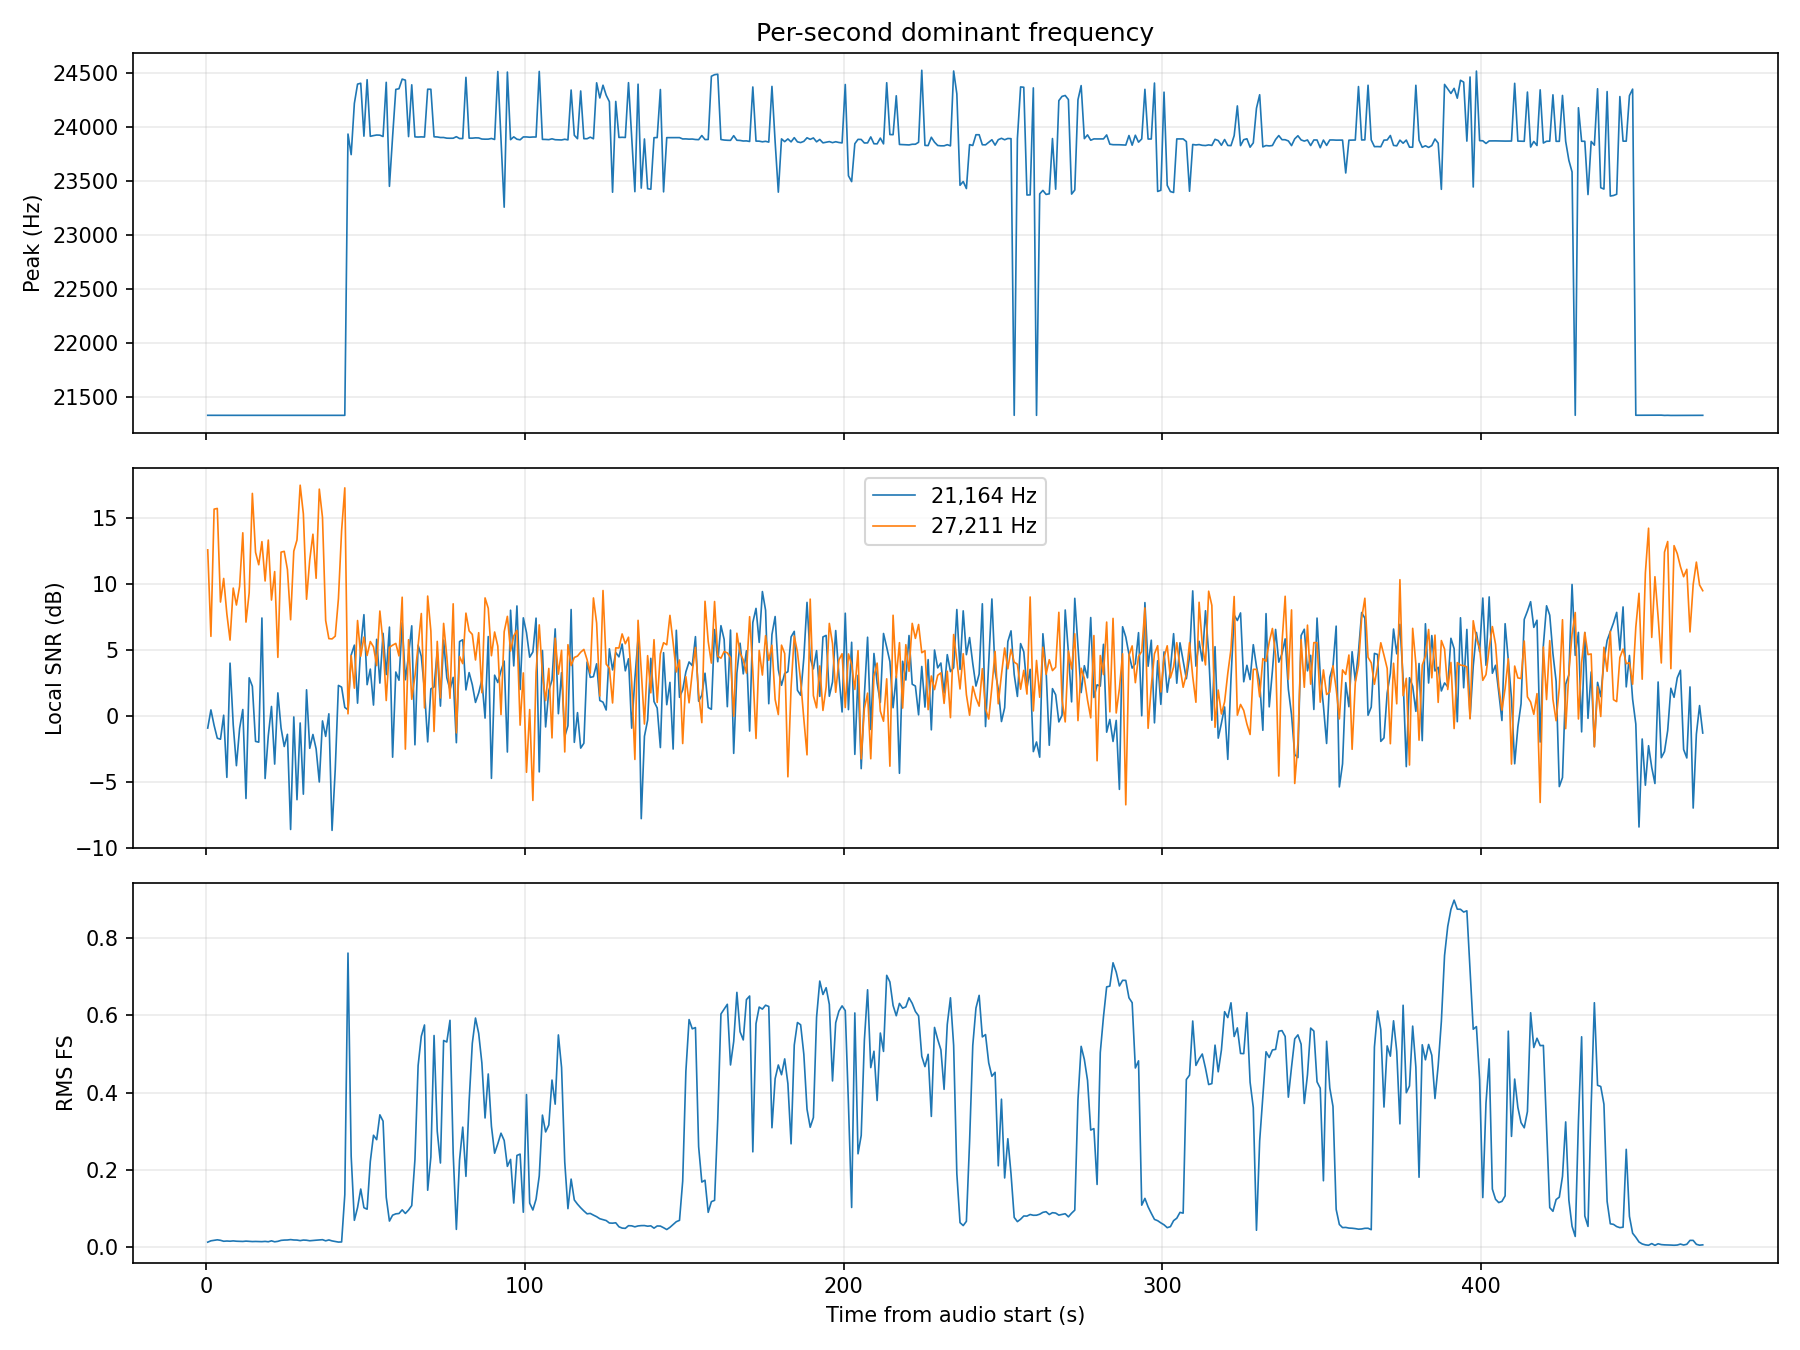

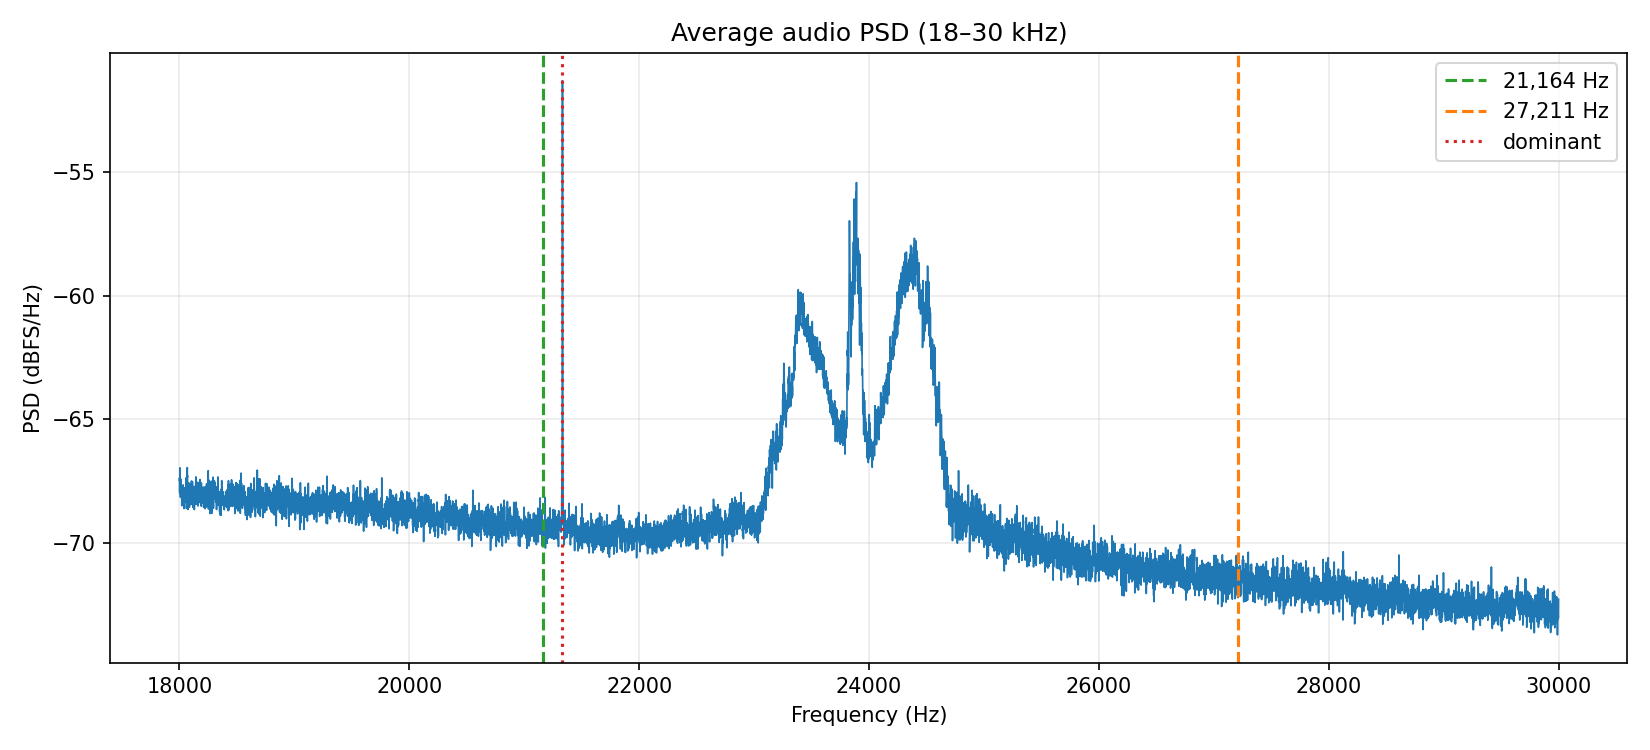

In [4]:
from IPython.display import Image, display
display(Image(filename=str(output_dir / 'frequency_snr_rms_time.png')))
display(Image(filename=str(output_dir / 'average_psd_18_30khz.png')))

## Takeaways

1. Use the first 0–43 s interval as the best stationary baseline in this bag. Its ~21,332.86 Hz line has only ~0.067 Hz per-second frequency standard deviation and no >90° phase steps at 42.7 ms resolution.
2. The middle interval is a propulsion/armed-state interference case, not a clean oscillator-drift baseline. Approximately 6% of all channel-0 samples in the whole bag clip; clipping is concentrated in this interval.
3. DVL acoustic was already enabled during the quiet opening interval, while severe interference starts with ALT_HOLD arming. This implicates thruster/vehicle actuation more strongly than DVL-only operation.
4. Neither competition nominal frequency is the dominant quiet-state line. Confirm what source generated ~21,332.86 Hz before treating it as the pinger.
5. The bit-identical stereo channels prevent common-versus-differential phase diagnosis in this recording.